# Global Fragility Scored Current World

This notebook applies the existing global fragility framework to present-day global conditions through a manual scoring workflow.

It does not fetch live data, does not invent scores, and does not produce a collapse prediction. Its purpose is to help you manually score current global conditions against historically recurrent fragility patterns using the protocol already created in this project.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

## Load Templates And Protocol

The notebook uses the fixed historical weights from `global_fragility_current_scoring_template.csv` and the narrative scoring guidance from `global_scoring_protocol.md`.

In [12]:
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

template_path = project_root / "data" / "processed" / "global_fragility_current_scoring_template.csv"
protocol_path = project_root / "references" / "methodology" / "global_scoring_protocol.md"

scoring_df = pd.read_csv(template_path)
protocol_text = protocol_path.read_text(encoding="utf-8")

scoring_df["evidence_notes"] = scoring_df["evidence_notes"].fillna("")
scoring_df["confidence_level"] = scoring_df["confidence_level"].fillna("")

role_map = {factor_name: "stress" for factor_name in scoring_df["factor_name"]}
role_map["adaptive_capacity_resilience"] = "resilience"
scoring_df["role"] = scoring_df["factor_name"].map(role_map)

display(Markdown("**Scoring protocol loaded** from `references/methodology/global_scoring_protocol.md`. Use that document as the scoring standard when assigning present-day values."))
display(scoring_df)

**Scoring protocol loaded** from `references/methodology/global_scoring_protocol.md`. Use that document as the scoring standard when assigning present-day values.

,factor_name,historical_category,historical_weight,current_global_score_0_to_3,confidence_level,evidence_notes,weighted_score,role
0,legitimacy_crisis,political,0.106313,2,medium,Global democratic legitimacy is under broad st...,NaN,stress
1,geopolitical_instability,military_geopolitical,0.100526,3,high,Russia-Ukraine war and wider Middle East insta...,NaN,stress
2,adaptive_capacity_resilience,resilience_institutional,0.098742,2,medium,The global system still has meaningful resilie...,NaN,resilience
3,political_fragmentation_polarization,political,0.096189,2,medium,Growing bloc polarization and widespread polit...,NaN,stress
4,trade_disruption,economic,0.094495,3,high,Energy and shipping disruptions are pushing up...,NaN,stress
5,conflict_pressure,military_geopolitical,0.089513,3,high,Multiple active wars with cross-border spillov...,NaN,stress
6,fiscal_strain,economic,0.082360,1,low,The global economy remains relatively resilien...,NaN,stress
7,urban_social_stress,social,0.079924,2,medium,High forced displacement and persistent social...,NaN,stress
8,institutional_rigidity,political+resilience_institutional,0.079556,2,medium,"Institutions are responding, but slow adaptati...",NaN,stress
9,food_insecurity,economic+environmental,0.075357,2,high,Large-scale hunger and acute food insecurity r...,NaN,stress


## Manual Entry Workflow

You can either edit `data/processed/global_fragility_current_scoring_template.csv` directly and rerun the notebook, or paste updates into the dictionary below.

Allowed score values are:

- `0 = absent / negligible`
- `1 = low`
- `2 = moderate`
- `3 = high`

In [13]:
manual_updates = {
    # "legitimacy_crisis": {
    #     "current_global_score_0_to_3": 2,
    #     "confidence_level": "medium",
    #     "evidence_notes": "Paste evidence summary here.",
    # },
}

for factor_name, updates in manual_updates.items():
    row_mask = scoring_df["factor_name"].eq(factor_name)
    if not row_mask.any():
        raise KeyError(f"Unknown factor_name: {factor_name}")
    for key, value in updates.items():
        if key in scoring_df.columns:
            scoring_df.loc[row_mask, key] = value

display(scoring_df)

,factor_name,historical_category,historical_weight,current_global_score_0_to_3,confidence_level,evidence_notes,weighted_score,role
0,legitimacy_crisis,political,0.106313,2,medium,Global democratic legitimacy is under broad st...,NaN,stress
1,geopolitical_instability,military_geopolitical,0.100526,3,high,Russia-Ukraine war and wider Middle East insta...,NaN,stress
2,adaptive_capacity_resilience,resilience_institutional,0.098742,2,medium,The global system still has meaningful resilie...,NaN,resilience
3,political_fragmentation_polarization,political,0.096189,2,medium,Growing bloc polarization and widespread polit...,NaN,stress
4,trade_disruption,economic,0.094495,3,high,Energy and shipping disruptions are pushing up...,NaN,stress
5,conflict_pressure,military_geopolitical,0.089513,3,high,Multiple active wars with cross-border spillov...,NaN,stress
6,fiscal_strain,economic,0.082360,1,low,The global economy remains relatively resilien...,NaN,stress
7,urban_social_stress,social,0.079924,2,medium,High forced displacement and persistent social...,NaN,stress
8,institutional_rigidity,political+resilience_institutional,0.079556,2,medium,"Institutions are responding, but slow adaptati...",NaN,stress
9,food_insecurity,economic+environmental,0.075357,2,high,Large-scale hunger and acute food insecurity r...,NaN,stress


## Calculate Weighted Scores

The historical weights remain fixed. Once manual scores are entered, the notebook computes weighted contributions automatically.

In [14]:
score_numeric = pd.to_numeric(scoring_df["current_global_score_0_to_3"], errors="coerce")
invalid_mask = score_numeric.notna() & ~score_numeric.isin([0, 1, 2, 3])
if invalid_mask.any():
    invalid_rows = scoring_df.loc[invalid_mask, ["factor_name", "current_global_score_0_to_3"]]
    raise ValueError(f"Scores must be 0, 1, 2, or 3. Invalid rows:\n{invalid_rows}")

scoring_df["score_numeric"] = score_numeric
scoring_df["weighted_score"] = scoring_df["historical_weight"] * (scoring_df["score_numeric"] / 3)
scoring_df["net_fragility_contribution"] = scoring_df["weighted_score"]

resilience_mask = scoring_df["role"].eq("resilience") & scoring_df["score_numeric"].notna()
scoring_df.loc[resilience_mask, "net_fragility_contribution"] = (
    scoring_df.loc[resilience_mask, "historical_weight"] * (1 - (scoring_df.loc[resilience_mask, "score_numeric"] / 3))
)

display(scoring_df[[
    "factor_name",
    "historical_category",
    "historical_weight",
    "current_global_score_0_to_3",
    "confidence_level",
    "evidence_notes",
    "weighted_score",
]])

,factor_name,historical_category,historical_weight,current_global_score_0_to_3,confidence_level,evidence_notes,weighted_score
0,legitimacy_crisis,political,0.106313,2,medium,Global democratic legitimacy is under broad st...,0.070875
1,geopolitical_instability,military_geopolitical,0.100526,3,high,Russia-Ukraine war and wider Middle East insta...,0.100526
2,adaptive_capacity_resilience,resilience_institutional,0.098742,2,medium,The global system still has meaningful resilie...,0.065828
3,political_fragmentation_polarization,political,0.096189,2,medium,Growing bloc polarization and widespread polit...,0.064126
4,trade_disruption,economic,0.094495,3,high,Energy and shipping disruptions are pushing up...,0.094495
5,conflict_pressure,military_geopolitical,0.089513,3,high,Multiple active wars with cross-border spillov...,0.089513
6,fiscal_strain,economic,0.082360,1,low,The global economy remains relatively resilien...,0.027453
7,urban_social_stress,social,0.079924,2,medium,High forced displacement and persistent social...,0.053283
8,institutional_rigidity,political+resilience_institutional,0.079556,2,medium,"Institutions are responding, but slow adaptati...",0.053037
9,food_insecurity,economic+environmental,0.075357,2,high,Large-scale hunger and acute food insecurity r...,0.050238


## Summary Box

In [15]:
entered_mask = scoring_df["score_numeric"].notna()
stress_mask = scoring_df["role"].eq("stress")
stress_entered = stress_mask & entered_mask
resilience_entered = scoring_df["role"].eq("resilience") & entered_mask

entered_weight_total = scoring_df.loc[entered_mask, "historical_weight"].sum()
stress_weight_total = scoring_df.loc[stress_mask, "historical_weight"].sum()
resilience_weight_total = scoring_df.loc[scoring_df["role"].eq("resilience"), "historical_weight"].sum()

total_weighted_score = scoring_df.loc[entered_mask, "weighted_score"].sum() if entered_mask.any() else pd.NA
total_weighted_stress_score = (
    100 * scoring_df.loc[stress_entered, "weighted_score"].sum() / stress_weight_total
    if stress_entered.any() else pd.NA
)
total_weighted_resilience_score = (
    100 * scoring_df.loc[resilience_entered, "weighted_score"].sum() / resilience_weight_total
    if resilience_entered.any() else pd.NA
)
net_global_fragility_score = (
    100 * scoring_df.loc[entered_mask, "net_fragility_contribution"].sum() / entered_weight_total
    if entered_mask.any() else pd.NA
)
normalized_0_to_100_index = net_global_fragility_score

def interpret_band(value):
    if pd.isna(value):
        return "No score yet"
    if value <= 20:
        return "Low overlap"
    if value <= 40:
        return "Mild fragility"
    if value <= 60:
        return "Moderate fragility"
    if value <= 80:
        return "High fragility"
    return "Severe systemic stress"

summary_md = f"""
### Global Fragility Summary

- Entered factors: **{int(entered_mask.sum())} / {len(scoring_df)}**
- Total weighted score: **{'n/a' if pd.isna(total_weighted_score) else round(float(total_weighted_score), 3)}**
- Total weighted stress score: **{'n/a' if pd.isna(total_weighted_stress_score) else round(float(total_weighted_stress_score), 2)}**
- Total weighted resilience score: **{'n/a' if pd.isna(total_weighted_resilience_score) else round(float(total_weighted_resilience_score), 2)}**
- Net global fragility score: **{'n/a' if pd.isna(net_global_fragility_score) else round(float(net_global_fragility_score), 2)}**
- Normalized 0-100 Global Fragility Index: **{'n/a' if pd.isna(normalized_0_to_100_index) else round(float(normalized_0_to_100_index), 2)}**
- Interpretation band: **{interpret_band(normalized_0_to_100_index)}**
"""

display(Markdown(summary_md))

if not entered_mask.all():
    display(Markdown("**Status note**: the scoring sheet is still incomplete, so the current summary should be treated as provisional until all desired factors are scored."))


### Global Fragility Summary

- Entered factors: **12 / 12**
- Total weighted score: **0.766**
- Total weighted stress score: **77.73**
- Total weighted resilience score: **66.67**
- Net global fragility score: **73.35**
- Normalized 0-100 Global Fragility Index: **73.35**
- Interpretation band: **High fragility**


## Final Scoring Table

In [16]:
final_scoring_table = scoring_df[[
    "factor_name",
    "historical_category",
    "current_global_score_0_to_3",
    "historical_weight",
    "weighted_score",
    "confidence_level",
    "evidence_notes",
]].copy()

display(final_scoring_table)

,factor_name,historical_category,current_global_score_0_to_3,historical_weight,weighted_score,confidence_level,evidence_notes
0,legitimacy_crisis,political,2,0.106313,0.070875,medium,Global democratic legitimacy is under broad st...
1,geopolitical_instability,military_geopolitical,3,0.100526,0.100526,high,Russia-Ukraine war and wider Middle East insta...
2,adaptive_capacity_resilience,resilience_institutional,2,0.098742,0.065828,medium,The global system still has meaningful resilie...
3,political_fragmentation_polarization,political,2,0.096189,0.064126,medium,Growing bloc polarization and widespread polit...
4,trade_disruption,economic,3,0.094495,0.094495,high,Energy and shipping disruptions are pushing up...
5,conflict_pressure,military_geopolitical,3,0.089513,0.089513,high,Multiple active wars with cross-border spillov...
6,fiscal_strain,economic,1,0.082360,0.027453,low,The global economy remains relatively resilien...
7,urban_social_stress,social,2,0.079924,0.053283,medium,High forced displacement and persistent social...
8,institutional_rigidity,political+resilience_institutional,2,0.079556,0.053037,medium,"Institutions are responding, but slow adaptati..."
9,food_insecurity,economic+environmental,2,0.075357,0.050238,high,Large-scale hunger and acute food insecurity r...


## Weighted Contribution By Factor

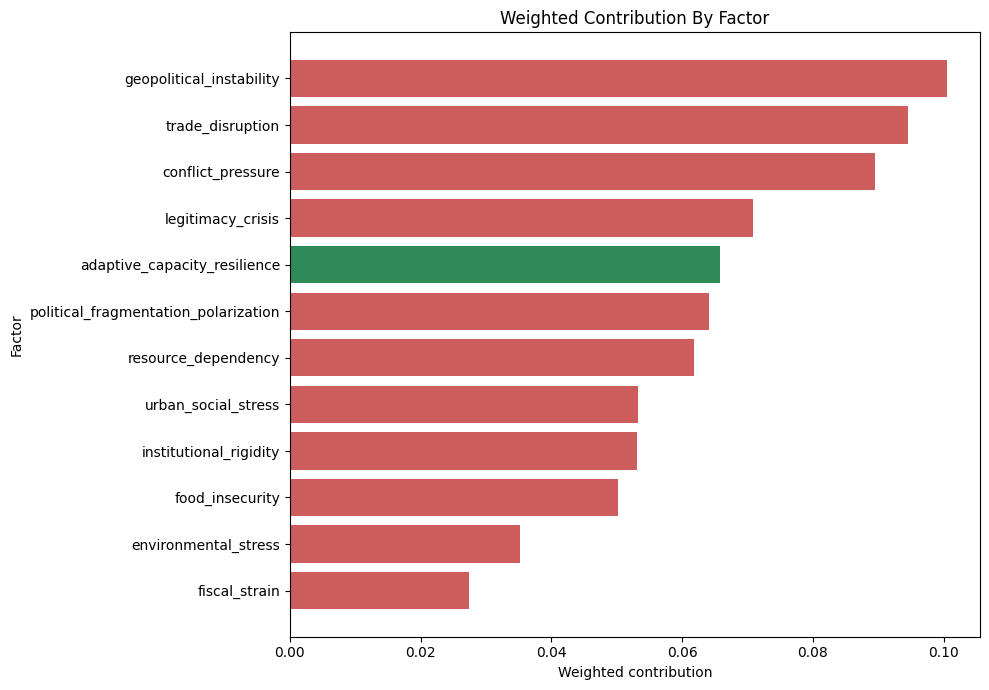

In [17]:
chart_df = scoring_df.loc[entered_mask, ["factor_name", "weighted_score", "role"]].copy()

if chart_df.empty:
    display(Markdown("No present-day scores entered yet, so the weighted contribution chart is not shown."))
else:
    chart_df = chart_df.sort_values("weighted_score")
    colors = chart_df["role"].map({"stress": "indianred", "resilience": "seagreen"})
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(chart_df["factor_name"], chart_df["weighted_score"], color=colors)
    ax.set_title("Weighted Contribution By Factor")
    ax.set_xlabel("Weighted contribution")
    ax.set_ylabel("Factor")
    plt.tight_layout()
    plt.show()

## Current World Interpretation

In [18]:
if not entered_mask.any():
    display(Markdown("No current-world interpretation is available yet because no manual scores have been entered."))
else:
    interpretation_md = f"""
### Current World Interpretation

Based on the manually entered scores so far, the current world shows a **{interpret_band(normalized_0_to_100_index).lower()}** level of overlap with historically recurrent fragility patterns in the dataset.

This is an overlap measure, not a forecast. Its meaning depends on the quality of the evidence notes and the completeness of the factor scoring sheet.
"""
    display(Markdown(interpretation_md))


### Current World Interpretation

Based on the manually entered scores so far, the current world shows a **high fragility** level of overlap with historically recurrent fragility patterns in the dataset.

This is an overlap measure, not a forecast. Its meaning depends on the quality of the evidence notes and the completeness of the factor scoring sheet.


## Main Global Stress Drivers

In [19]:
stress_driver_df = scoring_df.loc[stress_entered, ["factor_name", "weighted_score", "confidence_level", "evidence_notes"]].sort_values("weighted_score", ascending=False)

if stress_driver_df.empty:
    display(Markdown("No stress-factor scores have been entered yet."))
else:
    display(stress_driver_df)

,factor_name,weighted_score,confidence_level,evidence_notes
1,geopolitical_instability,0.100526,high,Russia-Ukraine war and wider Middle East insta...
4,trade_disruption,0.094495,high,Energy and shipping disruptions are pushing up...
5,conflict_pressure,0.089513,high,Multiple active wars with cross-border spillov...
0,legitimacy_crisis,0.070875,medium,Global democratic legitimacy is under broad st...
3,political_fragmentation_polarization,0.064126,medium,Growing bloc polarization and widespread polit...
10,resource_dependency,0.061805,high,Current energy shocks show continued dependenc...
7,urban_social_stress,0.053283,medium,High forced displacement and persistent social...
8,institutional_rigidity,0.053037,medium,"Institutions are responding, but slow adaptati..."
9,food_insecurity,0.050238,high,Large-scale hunger and acute food insecurity r...
11,environmental_stress,0.035220,high,"Record heat, rising climate disruption, and gr..."


## Main Resilience / Stabilizing Factors

In [20]:
resilience_df = scoring_df.loc[resilience_entered, ["factor_name", "weighted_score", "confidence_level", "evidence_notes"]].sort_values("weighted_score", ascending=False)

if resilience_df.empty:
    display(Markdown("No resilience-factor scores have been entered yet."))
else:
    display(resilience_df)

,factor_name,weighted_score,confidence_level,evidence_notes
2,adaptive_capacity_resilience,0.065828,medium,The global system still has meaningful resilie...


## Limits of This Score

- The historical weights are fixed and should be treated as a comparative framework, not as universal laws.
- This score depends entirely on the present-day evidence and confidence judgments entered by the user.
- Incomplete scoring produces provisional results.
- A high score indicates stronger overlap with historical fragility patterns, not a probability of collapse.
- A low score indicates lower overlap within this framework, not proof of systemic safety.